In [144]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [145]:
df = pd.read_csv("Netflix_stock_data.csv")
df.head()



,Date,Close,High,Low,Open,Volume
0,2002-05-23,0.119643,0.124286,0.114571,0.115643,1047900000
1,2002-05-24,0.121000,0.122500,0.119714,0.121429,111048000
2,2002-05-28,0.115714,0.123214,0.115714,0.121357,66094000
3,2002-05-29,0.110357,0.116429,0.108571,0.116429,67578000
4,2002-05-30,0.107143,0.110786,0.107143,0.110786,101542000


In [146]:
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5959 entries, 0 to 5958
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    5959 non-null   object 
 1   Close   5959 non-null   float64
 2   High    5959 non-null   float64
 3   Low     5959 non-null   float64
 4   Open    5959 non-null   float64
 5   Volume  5959 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 279.5+ KB


In [147]:
df.describe()



,Close,High,Low,Open,Volume
count,5959.000000,5959.000000,5959.000000,5959.000000,5.959000e+03
mean,19.793527,20.071195,19.500291,19.789897,1.485652e+08
std,27.840294,28.185715,27.471964,27.838418,1.822153e+08
min,0.037286,0.041071,0.034643,0.037786,2.856000e+06
25%,0.440571,0.448500,0.430143,0.438429,5.212800e+07
50%,5.074286,5.192286,4.998286,5.077857,9.116700e+07
75%,33.754499,34.213501,33.160999,33.715500,1.775410e+08
max,133.912994,134.115005,132.121002,133.822998,3.234140e+09


In [148]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

df.isnull().sum()



Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

In [149]:
df = df.dropna()

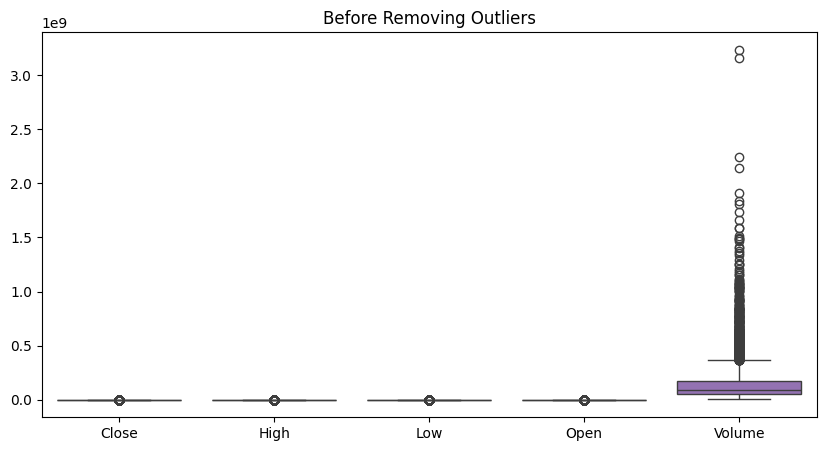

In [150]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df.select_dtypes(include=np.number))
plt.title("Before Removing Outliers")
plt.show()



In [151]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

df = df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]

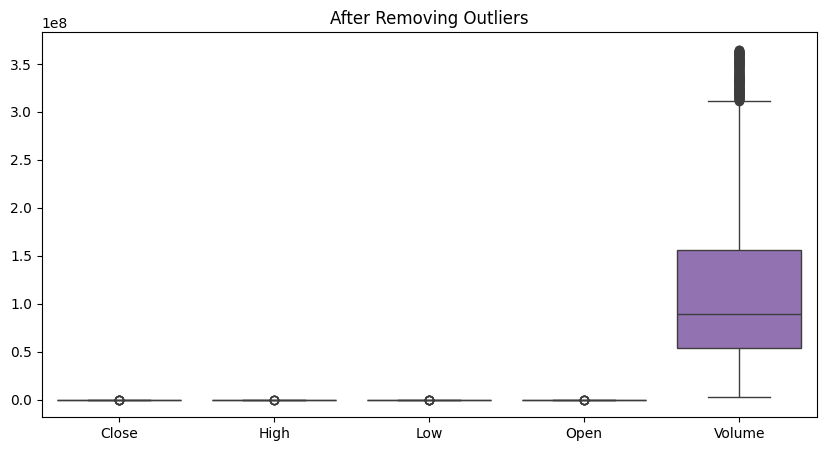

In [152]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df.select_dtypes(include=np.number))
plt.title("After Removing Outliers")
plt.show()



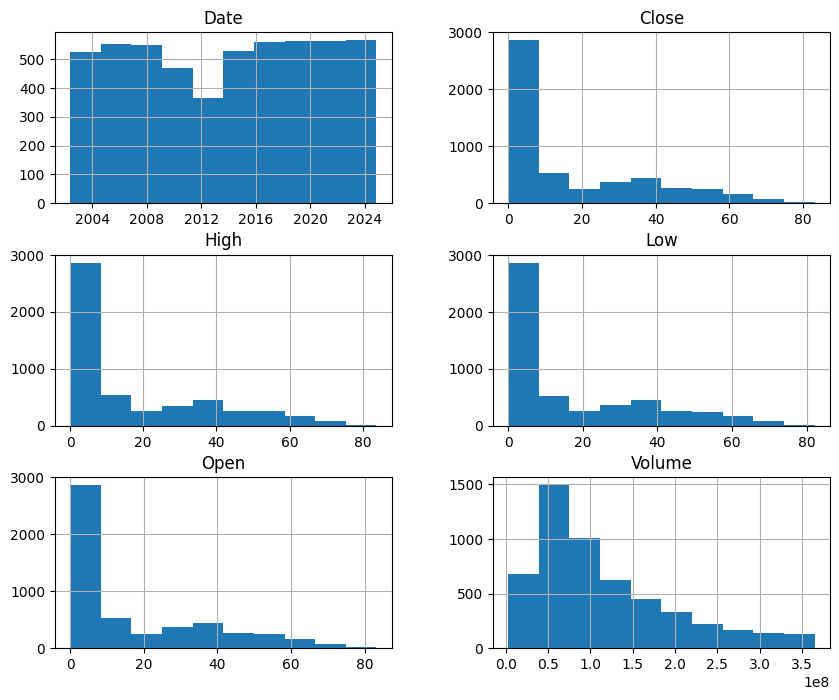

In [153]:
df.hist(figsize=(10,8))
plt.show()



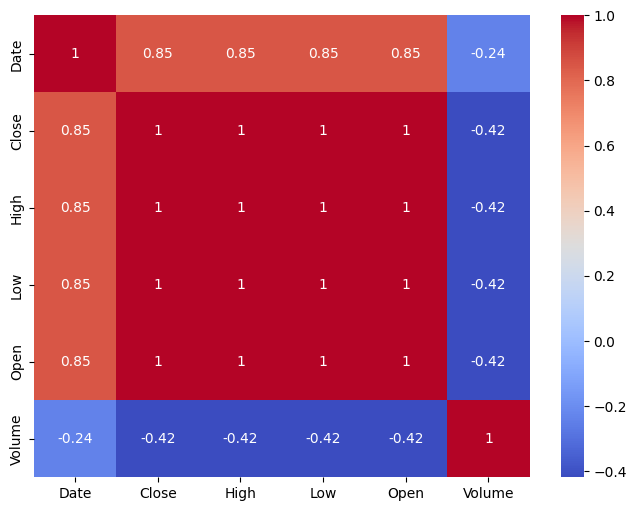

In [154]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()



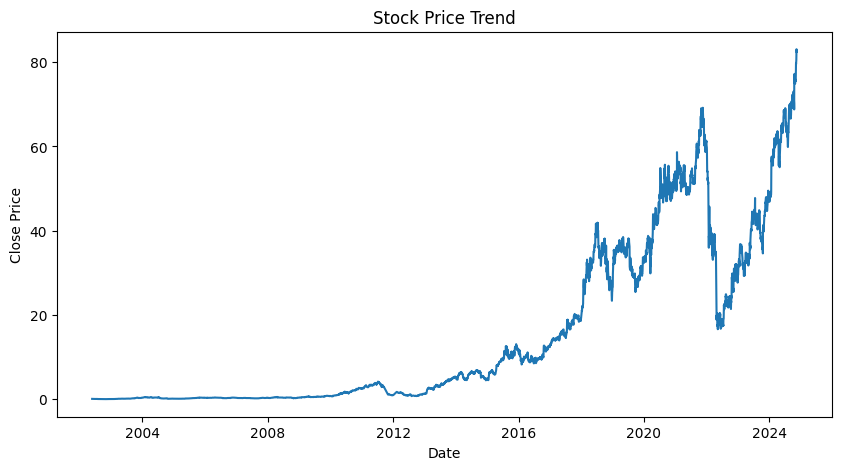

In [155]:
plt.figure(figsize=(10,5))
plt.plot(df['Date'], df['Close'])
plt.title("Stock Price Trend")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.show()



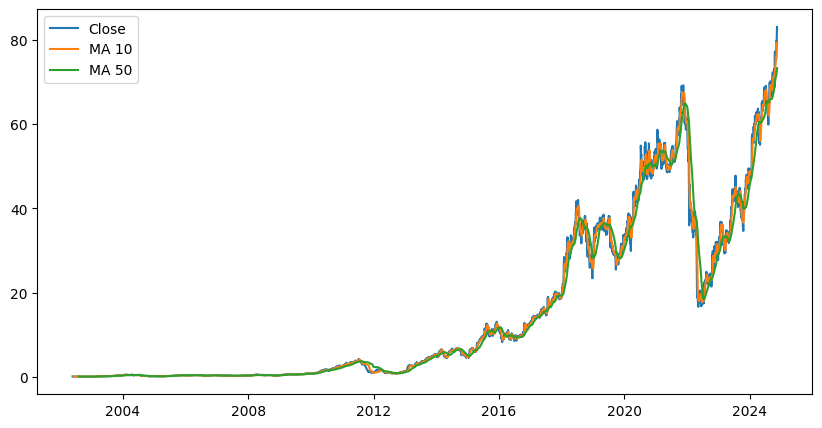

In [156]:
df['MA_10'] = df['Close'].rolling(10).mean()
df['MA_50'] = df['Close'].rolling(50).mean()

plt.figure(figsize=(10,5))
plt.plot(df['Date'], df['Close'], label='Close')
plt.plot(df['Date'], df['MA_10'], label='MA 10')
plt.plot(df['Date'], df['MA_50'], label='MA 50')
plt.legend()
plt.show()



In [157]:
df['Returns'] = df['Close'].pct_change()

In [158]:
volatility = df['Returns'].std()
print("Volatility:", volatility*100)



Volatility: 3.844295082957424


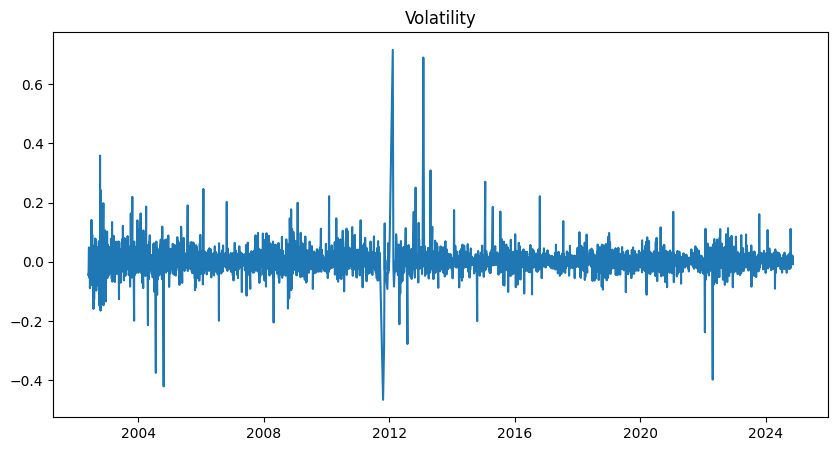

In [159]:
plt.figure(figsize=(10,5))
plt.plot(df['Date'], df['Returns'])
plt.title("Volatility")
plt.show()



In [160]:
df['Trend'] = np.where(df['Close'].shift(-1) > df['Close'], 1, 0)

In [161]:
X = df[['Open', 'High', 'Low', 'Volume']]
y = df['Trend']

X = X[:-1]
y = y[:-1]

In [162]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [163]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [164]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy*100)



Accuracy: 48.47036328871893


In [165]:
sample = X_test.iloc[0].values.reshape(1, -1)
prediction = model.predict(sample)

if prediction[0] == 1:
    print("Stock will go UP")
else:
    print("Stock will go DOWN")



Stock will go UP


C:\Users\manod\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [166]:
print("Volatility:", volatility*100)
print("Accuracy:", accuracy*100)

if volatility < 0.02:
    print("Stock is STABLE")
else:
    print("Stock is VOLATILE")



Volatility: 3.844295082957424
Accuracy: 48.47036328871893
Stock is VOLATILE
